In [1]:
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import dask.array as da
import dask.dataframe as dd
import xarray as xr
from xnemogcm import open_domain_cfg, get_metrics
import xgcm
import cartopy.crs as ccrs
import cmocean
import numpy as np
from scipy.stats import linregress
import datetime
import pandas as pd

# Add SouthernDemons library to PATH
sys.path.append(os.path.abspath("../lib/"))
from teos_ten import teos_sigma0
import datesandtime
# Subdomain information (As inputted into TRACMASS, note non-pythonic indexing)
imindom = 1
imaxdom = 1440
jmindom = 1
jmaxdom = 400
kmindom = 1
kmaxdom = 75

In [2]:

# BWD
# data_dir = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/ORCA025_bwd")
# out_dir = os.path.abspath(data_dir + "/OUTPUT.ORCA025_revised/")

# #FWD
data_dir = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/ORCA025_fwd/")
out_dir = os.path.abspath(data_dir + "/OUTPUT.ORCA025_fwd_extra/")

# Location of masks and grid information for the model
grid_path = os.path.abspath("/gws/nopw/j04/bas_pog/astyles/ORCA025_fwd/topo" )
grid_files = ['mask.nc','mesh_hgr.nc','mesh_zgr.nc']
# mask_path = os.path.abspath("/gws/nopw/j04/aopp/astyles/TRACMASS_DATA/DRAKKAR_SET/ORCA025/topo/mask.nc")
# hgrid_path = os.path.abspath("/gws/nopw/j04/aopp/astyles/TRACMASS_DATA/DRAKKAR_SET/ORCA025/topo/mesh_hgr.nc")
# zgrid_path = os.path.abspath("/gws/nopw/j04/aopp/astyles/TRACMASS_DATA/DRAKKAR_SET/ORCA025/topo/mesh_zgr.nc")

#cal_months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df_ini = dd.read_parquet(out_dir + f"/df_ini.combined.parquet")

#df_out = dd.read_parquet(out_dir + f"/df_out.combined.parquet")
#df_vent = dd.read_parquet(out_dir + f"/df_vent.parquet")
ds_domain = open_domain_cfg( datadir=grid_path, files = grid_files )

#print(df_ini.dtypes) 
#print(ds_domain.e3t_0.values)
xvals = ds_domain.e1t.values # xvals depend on y index   ###

yvals = ds_domain.e2t.values   ###SHOULD 3D, DEPEND X,Y
print(np.shape(xvals))
print(np.shape(yvals))                       
zarr = ds_domain.e3t_0.values   #z,y,x indexes


(1021, 1442)
(1021, 1442)


In [26]:
ds_domain.gdept_1d.values

array([5.05760017e-01, 1.55585530e+00, 2.66768175e+00, 3.85627974e+00,
       5.14036125e+00, 6.54303362e+00, 8.09251839e+00, 9.82275043e+00,
       1.17736795e+01, 1.39910380e+01, 1.65253215e+01, 1.94298028e+01,
       2.27576162e+01, 2.65583009e+01, 3.08745618e+01, 3.57402047e+01,
       4.11800247e+01, 4.72118941e+01, 5.38506372e+01, 6.11128402e+01,
       6.90216839e+01, 7.76111618e+01, 8.69294254e+01, 9.70413126e+01,
       1.08030281e+02, 1.20000001e+02, 1.33075822e+02, 1.47406245e+02,
       1.63164456e+02, 1.80549922e+02, 1.99789960e+02, 2.21141180e+02,
       2.44890622e+02, 2.71356387e+02, 3.00887515e+02, 3.33862834e+02,
       3.70688484e+02, 4.11793845e+02, 4.57625617e+02, 5.08639904e+02,
       5.65292274e+02, 6.28025970e+02, 6.97258648e+02, 7.73368259e+02,
       8.56678942e+02, 9.47447897e+02, 1.04585430e+03, 1.15199125e+03,
       1.26586142e+03, 1.38737698e+03, 1.51636363e+03, 1.65256845e+03,
       1.79567082e+03, 1.94529547e+03, 2.10102652e+03, 2.26242161e+03,
      

In [3]:

def plot_depth(ax,df): # plot seeding depth & volume in density class, integrated around longitudes
   
    #df_densest= df_densest[df_densest['year_o']>1983]
    df_group = df.groupby(['binnedy_i','bin_depth_i'])
    count = df_group.sum('subvol')
    count = count.reset_index()
    # Pivot the DataFrame to get a 2D grid
    grid = count.pivot(index="bin_depth_i", columns="binnedy_i", values="subvol")
    yy, zz = np.meshgrid(grid.columns, grid.index)
    Z = grid.values
    cax = ax.pcolormesh(yy, zz, Z, cmap=cmocean.cm.thermal )
    return cax


In [27]:
##logical
#WHY ADD 1 IN PLOTS?
#CURRENT BEST

   


xmin, xmax = imindom, imaxdom
ymin, ymax = jmindom, jmaxdom
zmin, zmax = kmindom, kmaxdom

xbins = np.linspace(xmin-0.5, xmax+0.5, num=xmax-xmin+2)
ybins = np.linspace(ymin, ymax, num=ymax-ymin+1)
zbins = np.linspace(zmin, zmax, num=zmax-zmin+1)

xbins[0], xbins[-1] = -float("inf"), float("inf")
ybins[0], ybins[-1] = -float("inf"), float("inf")
zbins[0], zbins[-1] = -float("inf"), float("inf")


xcent = np.linspace(xmin, xmax, num=xmax-xmin+1)+1
ycent = np.linspace(ymin+0.5, ymax-0.5, num=ymax-ymin)+1
zcent = np.linspace(zmin+0.5, zmax-0.5, num=zmax-zmin)+1



print(xbins)
print(xcent)



#CORRECTED BINS

df_ini["binnedx_i"] = df_ini["x"].map_partitions(pd.cut, xbins, labels=xcent,right=False, retbins=False).astype(float)  
df_ini["binnedy_i"] = df_ini["y"].map_partitions(pd.cut, ybins, labels=ycent,right=False, retbins=False).astype(float)  
df_ini["bin_depth_i"] = df_ini["z"].map_partitions(pd.cut, zbins, labels=zcent, right=False,retbins=False).astype(float)  


#define pythonic indexes
df_ini['x_index'] = (df_ini['binnedx_i']-1).astype(int) 
df_ini['y_index'] = (df_ini['binnedy_i'] -1.5).astype(int) 
df_ini['z_index'] = (df_ini['bin_depth_i']-1.5).astype(int) 




[  -inf    1.5    2.5 ... 1438.5 1439.5    inf]
[   2.    3.    4. ... 1439. 1440. 1441.]


In [20]:
df_ini.head(4000)

,ntraj,x,y,z,subvol,time,boxface,temp,sal,density,density10,ntrajc,binnedx_i,binnedy_i,bin_depth_i,x_index,y_index,z_index
0,1,1.0,112.50,8.50,2.067663e+08,0.0,2,0.49,33.45,26.71,0.03,1,2.0,113.5,9.5,1,112,8
1,2,2.0,112.50,8.50,2.067663e+08,0.0,2,0.65,33.38,26.64,0.02,2,3.0,113.5,9.5,2,112,8
2,3,1.0,113.50,8.50,2.084569e+08,0.0,2,0.49,33.55,26.78,0.02,3,2.0,114.5,9.5,1,113,8
3,4,2.0,113.50,8.50,2.084569e+08,0.0,2,0.63,33.51,26.74,0.02,4,3.0,114.5,9.5,2,113,8
4,5,3.0,113.50,8.50,2.084569e+08,0.0,2,0.52,33.54,26.78,0.02,5,4.0,114.5,9.5,3,113,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,1.0,320.25,18.25,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3996,2.0,321.5,19.5,1,320,18
3996,3997,1.0,320.75,18.75,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3997,2.0,321.5,19.5,1,320,18
3997,3998,1.0,320.75,18.25,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3998,2.0,321.5,19.5,1,320,18
3998,3999,2.0,320.25,18.75,7.738618e+08,0.0,2,13.34,35.10,26.27,0.07,3999,3.0,321.5,19.5,2,320,18


In [15]:
xmin, xmax = imindom, imaxdom
ymin, ymax = jmindom, jmaxdom
zmin, zmax = kmindom, kmaxdom

xbins = np.linspace(xmin-0.5, xmax+0.5, num=xmax-xmin+2)
ybins = np.linspace(ymin-0.5, ymax+0.5, num=ymax-ymin+2)
zbins = np.linspace(zmin-0.5, zmax+0.5, num=zmax-zmin+2)

#to truncate



xbins[0], xbins[-1] = -float("inf"), float("inf")
ybins[0], ybins[-1] = -float("inf"), float("inf")
zbins[0], zbins[-1] = -float("inf"), float("inf")

xcent = np.linspace(xmin, xmax, num=xmax-xmin+1, dtype=int)+1
ycent = np.linspace(ymin, ymax, num=ymax-ymin+1, dtype=int)+1
zcent = np.linspace(zmin, zmax, num=zmax-zmin+1, dtype=int)+1



print(xbins)
print(xcent)



#CORRECTED BINS

df_ini["binnedx_i"] = df_ini["x"].map_partitions(pd.cut, xbins, labels=xcent,right=False, retbins=False).astype(int)
df_ini["binnedy_i"] = df_ini["y"].map_partitions(pd.cut, ybins, labels=ycent,right=False, retbins=False).astype(int)
df_ini["bin_depth_i"] = df_ini["z"].map_partitions(pd.cut, zbins, labels=zcent, right=False,retbins=False).astype(int)

df_ini['x_index'] = (df_ini['binnedx_i']-1).astype(int) 
df_ini['y_index'] = (df_ini['binnedy_i'] -1).astype(int) 
df_ini['z_index'] = (df_ini['bin_depth_i']-1).astype(int) 


[  -inf    1.5    2.5 ... 1438.5 1439.5    inf]
[   2    3    4 ... 1439 1440 1441]


In [16]:
df_ini.head(4000)

,ntraj,x,y,z,subvol,time,boxface,temp,sal,density,density10,ntrajc,binnedx_i,binnedy_i,bin_depth_i,x_index,y_index,z_index
0,1,1.0,112.50,8.50,2.067663e+08,0.0,2,0.49,33.45,26.71,0.03,1,2,114,10,1,113,9
1,2,2.0,112.50,8.50,2.067663e+08,0.0,2,0.65,33.38,26.64,0.02,2,3,114,10,2,113,9
2,3,1.0,113.50,8.50,2.084569e+08,0.0,2,0.49,33.55,26.78,0.02,3,2,115,10,1,114,9
3,4,2.0,113.50,8.50,2.084569e+08,0.0,2,0.63,33.51,26.74,0.02,4,3,115,10,2,114,9
4,5,3.0,113.50,8.50,2.084569e+08,0.0,2,0.52,33.54,26.78,0.02,5,4,115,10,3,114,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3996,1.0,320.25,18.25,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3996,2,321,19,1,320,18
3996,3997,1.0,320.75,18.75,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3997,2,322,20,1,321,19
3997,3998,1.0,320.75,18.25,7.738618e+08,0.0,2,13.32,35.11,26.28,0.09,3998,2,322,19,1,321,18
3998,3999,2.0,320.25,18.75,7.738618e+08,0.0,2,13.34,35.10,26.27,0.07,3999,3,321,20,2,320,19


In [31]:
df_ini.binnedx_i.compute()

0             1
1             1
2             1
3             1
4             2
           ... 
1504040    1438
1504041    1438
1504042    1438
1504043    1438
1504044    1438
Name: binnedx_i, Length: 482615340, dtype: int64

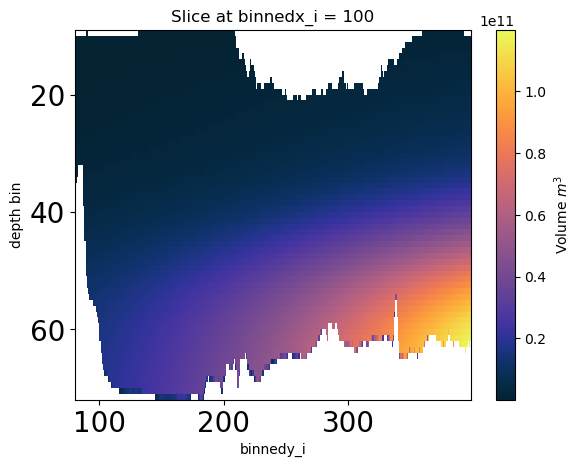

In [34]:
df_interest = df_ini[df_ini['binnedx_i']==1100].compute()
fig,ax = plt.subplots(1,1)
cax=plot_depth(ax,df_interest)
ax.tick_params(axis='x', which='both', labelbottom=True)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.invert_yaxis()
plt.title('Slice at binnedx_i = 100')
plt.xlabel('binnedy_i')
plt.ylabel('depth bin')

cbar=plt.colorbar(cax)
cbar.set_label('Volume $m^3$')


Text(0, 0.5, 'Volume of domain gridpoint (from ds_domain)')

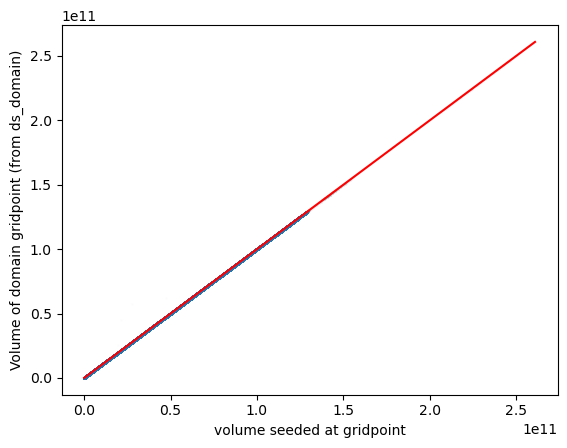

In [28]:
df_int = df_ini[['x_index','y_index','z_index','subvol']]

df_group = df_int.groupby(['x_index','y_index','z_index'])
vol = df_group.sum()[['subvol']]

vol = vol.compute().reset_index()

vol['ds_vol'] = xvals[vol['y_index'],vol['x_index']] *  yvals[vol['y_index'],vol['x_index']] * zarr[(vol['z_index']),vol['y_index'],vol['x_index']] 

plt.scatter(vol['subvol'],vol['ds_vol'],s=0.5,alpha=0.01)
plt.plot([0,vol['subvol'].max()],[0,vol['subvol'].max()],c='red')
plt.xlabel('volume seeded at gridpoint')
plt.ylabel('Volume of domain gridpoint (from ds_domain)')

In [7]:
print(abs(vol['ds_vol']-vol['subvol']).max())

29842503540.642124


In [8]:
vol['dif'] = vol['ds_vol']-vol['subvol']

In [9]:
vol_sort = vol.sort_values('dif')

In [10]:
vol_filt = vol[vol['z_index']<65]

In [11]:
print(abs(vol_filt['ds_vol']-vol_filt['subvol']).max())

4781.146102905273


In [21]:
vol_sort.head(300)

,x_index,y_index,z_index,subvol,ds_vol,dif
19630339,388,397,54,9.909501e+10,9.909501e+10,-4716.973145
21690518,978,394,54,8.448356e+10,8.448356e+10,-4664.969177
16268500,979,394,54,9.891736e+10,9.891736e+10,-4664.953720
13552640,976,393,54,9.225520e+10,9.225519e+10,-4648.055557
13555073,978,393,54,9.043481e+10,9.043480e+10,-4647.806396
...,...,...,...,...,...,...
4331034,1356,397,57,1.111188e+11,1.111188e+11,-4573.034714
20611628,741,397,57,1.111188e+11,1.111188e+11,-4573.034714
3215298,1426,397,57,1.111188e+11,1.111188e+11,-4573.034714
3256090,118,397,57,1.111188e+11,1.111188e+11,-4573.034714


In [ ]:
#for pandas dataframe
df = df_ini_pd[(df_ini_pd['binnedx_i'] == 1100) & (df_ini_pd['binnedy_i'] == 391.5)]

#print(df.head(npartitions=-1))

df_group = df.groupby("bin_depth_i", as_index=False).agg(
    {"subvol": "sum", **{col: "first" for col in df.columns if col != "bin_depth_i" and col != "subvol"}}
)


#print(df_group)



# Sort and reset index
vol = df_group.sort_values('bin_depth_i').reset_index(drop=True)


vol['ds_vol'] = (
    xvals[(vol['y_index']+1 ) , (vol['x_index']) ] *
    yvals[(vol['y_index']+1 ) , (vol['x_index']) ] *
    zarr[vol['z_index']+1 , vol['y_index']+1  , vol['x_index'] ]    
)
#print(vol[['binnedx_i','binnedy_i','bin_depth_i','subvol']].head())
# Plot
fig, ax = plt.subplots(1, 1)
plt.plot(vol.subvol, vol.z_index, label="Summed Subvol")
plt.plot(vol.ds_vol, vol.z_index, c='red', label="Volume from domain")
ax.invert_yaxis()

plt.title('Volume seeded at i_index=119, j_index=200')
plt.xlabel('volume $m^3$')
plt.ylabel('k_index (depth)')
plt.legend()

In [66]:
df_ini.head(500)

,ntraj,x,y,z,subvol,time,boxface,temp,sal,density,density10,ntrajc,binnedx_i,binnedy_i,bin_depth_i,x_index,y_index,z_index
0,1,1.0,112.50,8.5,2.067663e+08,0.0,2,0.49,33.45,26.71,0.03,1,2.0,113.5,9.5,1,112,8
1,2,2.0,112.50,8.5,2.067663e+08,0.0,2,0.65,33.38,26.64,0.02,2,3.0,113.5,9.5,2,112,8
2,3,1.0,113.50,8.5,2.084569e+08,0.0,2,0.49,33.55,26.78,0.02,3,2.0,114.5,9.5,1,113,8
3,4,2.0,113.50,8.5,2.084569e+08,0.0,2,0.63,33.51,26.74,0.02,4,3.0,114.5,9.5,2,113,8
4,5,3.0,113.50,8.5,2.084569e+08,0.0,2,0.52,33.54,26.78,0.02,5,4.0,114.5,9.5,3,113,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2.0,391.25,10.5,8.492446e+08,0.0,2,22.60,36.08,24.74,0.05,496,3.0,392.5,11.5,2,391,10
496,497,2.0,391.75,10.5,8.492446e+08,0.0,2,22.60,36.08,24.74,0.05,497,3.0,392.5,11.5,2,391,10
497,498,3.0,391.25,10.5,8.492446e+08,0.0,2,22.38,36.12,24.82,0.06,498,4.0,392.5,11.5,3,391,10
498,499,3.0,391.75,10.5,8.492446e+08,0.0,2,22.38,36.12,24.82,0.06,499,4.0,392.5,11.5,3,391,10


In [64]:
df_ini.head(500)

,ntraj,x,y,z,subvol,time,boxface,temp,sal,density,density10,ntrajc,binnedx_i,binnedy_i,bin_depth_i,x_index,y_index,z_index
0,1,1.0,112.50,8.5,2.067663e+08,0.0,2,0.49,33.45,26.71,0.03,1,2,113,9,1,112,8
1,2,2.0,112.50,8.5,2.067663e+08,0.0,2,0.65,33.38,26.64,0.02,2,3,113,9,2,112,8
2,3,1.0,113.50,8.5,2.084569e+08,0.0,2,0.49,33.55,26.78,0.02,3,2,114,9,1,113,8
3,4,2.0,113.50,8.5,2.084569e+08,0.0,2,0.63,33.51,26.74,0.02,4,3,114,9,2,113,8
4,5,3.0,113.50,8.5,2.084569e+08,0.0,2,0.52,33.54,26.78,0.02,5,4,114,9,3,113,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2.0,391.25,10.5,8.492446e+08,0.0,2,22.60,36.08,24.74,0.05,496,3,392,11,2,391,10
496,497,2.0,391.75,10.5,8.492446e+08,0.0,2,22.60,36.08,24.74,0.05,497,3,392,11,2,391,10
497,498,3.0,391.25,10.5,8.492446e+08,0.0,2,22.38,36.12,24.82,0.06,498,4,392,11,3,391,10
498,499,3.0,391.75,10.5,8.492446e+08,0.0,2,22.38,36.12,24.82,0.06,499,4,392,11,3,391,10


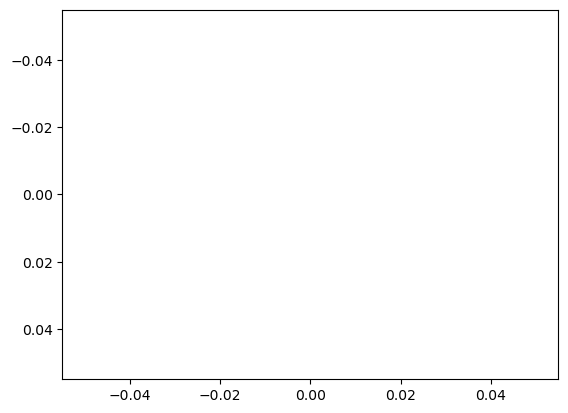

In [29]:


df = df_ini[(df_ini['binnedx_i'] == 1020) & (df_ini['binnedy_i'] == 151)]

#print(df.head(npartitions=-1))

df_group = df.groupby("z_index").sum()["subvol"].compute().reset_index()

# Merge back other columns if needed (they should be constant per group)
df_group["x_index"] = 1019
df_group["y_index"] = 150

# Sort and reset index
vol = df_group.sort_values('z_index').reset_index(drop=True)


vol['ds_vol'] = (
    xvals[(vol['y_index'] ) , (vol['x_index']) ] *
    yvals[(vol['y_index'] ) , (vol['x_index']) ] *
    zarr[vol['z_index'] , vol['y_index']  , vol['x_index'] ]    
)

#print(vol[['binnedx_i','binnedy_i','bin_depth_i','subvol']].head())
# Plot
fig, ax = plt.subplots(1, 1)
plt.plot(vol.subvol, vol.z_index, label="Summed Subvol")
plt.plot(vol.ds_vol, vol.z_index, c='red', label="Volume from domain")
ax.invert_yaxis()

# plt.title('Volume seeded at i_index=119, j_index=200')
# plt.xlabel('volume $m^3$')
# plt.ylabel('k_index (depth)')
# plt.legend()
# plt.savefig('../fig/banding/TRUNCATEx=119_y=200_depth_profile_fwd.png')
# plt.show()

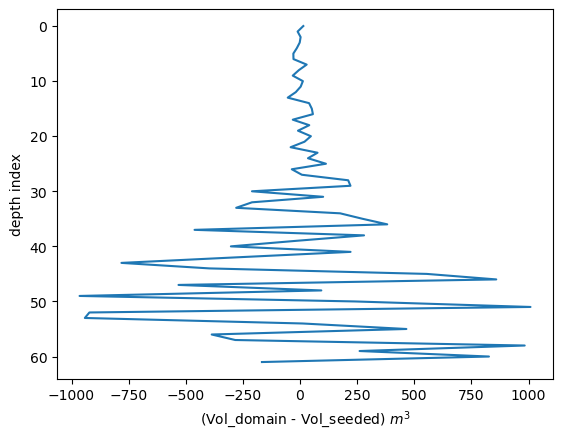

In [97]:
#plt.plot(vol['ds_vol'][:-1]-vol['subvol'][:-1])
fig, ax = plt.subplots()
ax.plot(vol['ds_vol']-vol['subvol'],np.arange(0,len(vol)))
ax.invert_yaxis()
plt.xlabel('(Vol_domain - Vol_seeded) $m^3$')
plt.ylabel('depth index')
plt.show()

In [16]:
df_ini_pd.z_index+1

0           8
1           8
2           8
3           8
4           8
           ..
1504040    66
1504041    66
1504042    66
1504043    66
1504044    66
Name: z_index, Length: 482615340, dtype: int64

In [20]:
zarr[:,200,200]

array([  1.02390661,   1.07928337,   1.14811918,   1.23374337,
         1.34018504,   1.47220538,   1.6352427 ,   1.83521193,
         2.07809483,   2.36927716,   2.71265437,   3.10964726,
         3.55841698,   4.05366256,   4.58731296,   5.15013812,
         5.73390766,   6.3334601 ,   6.94809589,   7.5820389 ,
         8.24409471,   8.94685991,   9.70584708,  10.53876724,
        11.46506447,  12.50569034,  13.68305332,  15.02106374,
        16.5452007 ,  18.28253761,  20.26167267,  22.51251659,
        25.06589343,  27.95291412,  31.20408794,  34.84814841,
        38.91058887,  43.41193172,  48.36579358,  53.77685622,
        59.63890301,  65.93312629,  72.62693916,  79.67352498,
        87.01231667,  94.57051508, 102.2656347 , 110.00892626,
       117.70939412, 125.27803203, 132.63186437, 139.69741243,
       146.41329662, 152.73181563, 158.61948268, 164.05662143,
       169.0362098 , 173.56220294, 177.64756953, 181.31224807,
       184.58118519, 187.48256749, 190.0463105 , 192.30

In [45]:
df_ini_pd.z_index

0           7
1           7
2           7
3           7
4           7
           ..
1504040    65
1504041    65
1504042    65
1504043    65
1504044    65
Name: z_index, Length: 482615340, dtype: int64

In [49]:
zarr[64][200][119]

np.float64(194.2820863715733)

In [63]:
zarr[65][1000][200]

np.float64(196.01289157631163)

In [29]:
df

,ntraj,x,y,z,subvol,time,boxface,temp,sal,density,density10,ntrajc,bin_depth_i,binnedx_i,binnedy_i,x_index,y_index,z_index
1059861,467,120.0,201.50,12.50,7.129585e+08,0.0,2,0.41,33.73,26.93,0.01,37109300,12.5,120,201.5,119,200,11
1060099,705,120.0,201.50,13.50,8.121851e+08,0.0,2,0.39,33.73,26.93,0.01,37109538,13.5,120,201.5,119,200,12
1060446,1052,120.0,201.50,14.50,9.191064e+08,0.0,2,0.36,33.73,26.94,0.02,37109885,14.5,120,201.5,119,200,13
1060924,1530,120.0,201.25,15.50,5.159365e+08,0.0,2,0.31,33.74,26.95,0.03,37110363,15.5,120,201.5,119,200,14
1060925,1531,120.0,201.75,15.50,5.159365e+08,0.0,2,0.31,33.74,26.95,0.03,37110364,15.5,120,201.5,119,200,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1554641,495247,120.0,201.86,66.25,9.859255e+08,0.0,2,-0.23,34.69,27.73,0.81,37604080,66.5,120,201.5,119,200,65
1554642,495248,120.0,201.92,66.75,9.859255e+08,0.0,2,-0.23,34.69,27.73,0.81,37604081,66.5,120,201.5,119,200,65
1554643,495249,120.0,201.92,66.25,9.859255e+08,0.0,2,-0.23,34.69,27.73,0.81,37604082,66.5,120,201.5,119,200,65
1554644,495250,120.0,201.97,66.75,9.859255e+08,0.0,2,-0.23,34.69,27.73,0.81,37604083,66.5,120,201.5,119,200,65


In [83]:
vol['ds_vol'] = (
    xvals[vol['binnedy_i'] , vol['binnedx_i'] ] *
    yvals[vol['binnedy_i'] , vol['binnedx_i'] ] *
    zarr[vol['bin_depth_i'] , vol['binnedy_i'] , vol['binnedx_i'] ]
)

In [85]:
xvals[vol['binnedy_i']

0     119
1     119
2     119
3     119
4     119
5     119
6     119
7     119
8     119
9     119
10    119
11    119
12    119
13    119
14    119
15    119
16    119
17    119
18    119
19    119
20    119
21    119
22    119
23    119
24    119
25    119
26    119
27    119
28    119
29    119
30    119
31    119
32    119
33    119
34    119
35    119
36    119
37    119
38    119
39    119
40    119
41    119
42    119
43    119
44    119
45    119
46    119
47    119
48    119
49    119
50    119
51    119
52    119
53    119
54    119
Name: binnedx_i, dtype: int64

In [88]:
df_ini.binnedy_i.min()

np.int64(1)